# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [99]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


In [100]:
mpg.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [101]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [102]:
# Correlation coefficients and p-values

#select numeric columns 
numeric_data = mpg.select_dtypes(include=[np.number]) #it returns them all because all of them is numeric

pairs = [('mpg', 'weight'),('mpg', 'horsepower'),('displacement', 'horsepower')]
corr_results = []

for var1, var2 in pairs:
    pearson_r, p_pearson = stats.pearsonr(mpg[var1], mpg[var2]) 
    spearman_r, p_spearman = stats.spearmanr(mpg[var1], mpg[var2])


    corr_results.append({
        'Pair' : f'{var1} & {var2}', 
        'Pearson r' : round(pearson_r, 4),
        'Pearson p' : f'{p_pearson: .4e}', 
        'Spearman r' : round(spearman_r, 4), 
        'Spearman p' : f'{p_spearman: .4e}'


    })
pd.DataFrame(corr_results)

,Pair,Pearson r,Pearson p,Spearman r,Spearman p
0,mpg & weight,-0.8322,6.0153e-102,-0.8756,2.6624e-125
1,mpg & horsepower,-0.7784,7.0320e-81,-0.8536,1.6194e-112
2,displacement & horsepower,0.8973,1.5109e-140,0.8762,1.1267e-125


In [103]:
#explanation for myself 
#Pearson və Spearman korrelyasiya əmsalları iki dəyişən arasında əlaqənin 
# gücünü və istiqamətini ölçmək üçün istifadə olunur. Amma yanaşmaları fərqlidir 
# — biri “düz xətt əlaqəsini”, digəri isə “ümumi (monoton) əlaqəni” ölçür.
#+1 → güclü müsbət əlaqə
#0 → əlaqə yoxdur
#-1 → güclü mənfi əlaqə
#Bu p-value-dur
#Statistik testin nəticəsidir
#“Bu əlaqə təsadüfi ola bilərmi?” sualına cavab verir
#Hipotez:
#H0 (null hypothesis): əlaqə yoxdur (r = 0)
#H1: əlaqə var
# Şərh:
#p < 0.05 → əlaqə statistik olaraq əhəmiyyətlidir 
#p ≥ 0.05 → əlaqə əhəmiyyətli deyil 

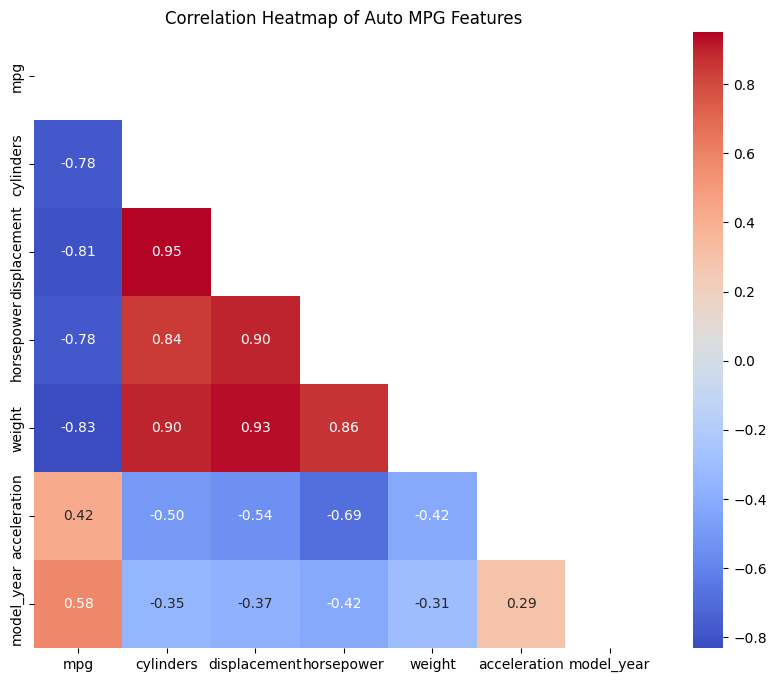

In [104]:
# Correlation heatmap
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(numeric_data.corr(), dtype=bool))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
plt.title('Correlation Heatmap of Auto MPG Features')
plt.show()

In [105]:
#explanation for myself
# Create a mask for the upper triangle of the correlation matrix.
# np.ones_like(...) creates a matrix of True values with the same shape as the correlation matrix.
# np.triu(...) keeps only the upper triangle (including the diagonal) as True and sets the lower part to False.
# This mask is later used in a heatmap to hide the redundant upper half of the symmetric correlation matrix.


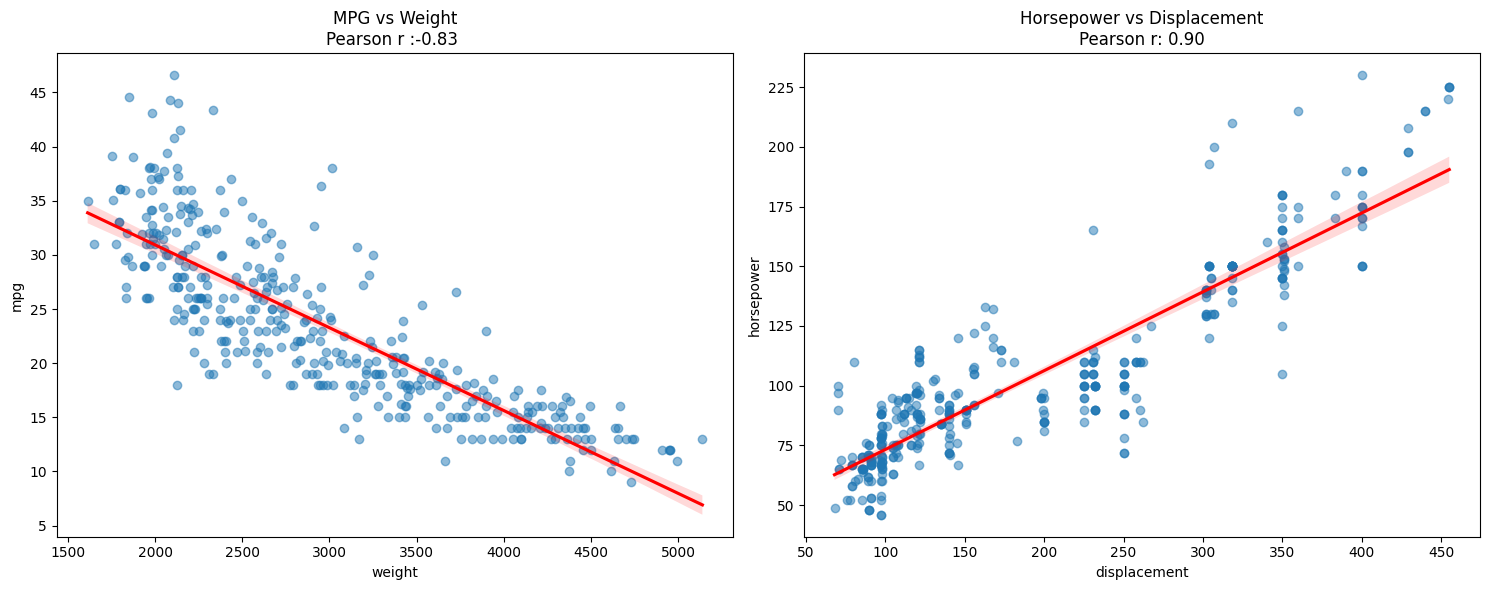

In [106]:
# Scatter plots with regression lines
fig, axes = plt.subplots(1,2, figsize=(15,6))

#Plot1 : mpg vs weight
sns.regplot(data=mpg, x='weight', y='mpg', ax=axes[0], 
            line_kws={'color' : 'red'}, scatter_kws={'alpha':0.5})
axes[0].set_title(f'MPG vs Weight\nPearson r :{mpg['mpg'].corr(mpg['weight']):.2f} ')


# Plot 2: horsepower vs displacement
sns.regplot(data=mpg, x='displacement', y='horsepower', ax=axes[1], 
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
axes[1].set_title(f"Horsepower vs Displacement\nPearson r: {mpg['horsepower'].corr(mpg['displacement']):.2f}")

plt.tight_layout()
plt.show()

In [107]:
#explanation for myself
#subplot 1,2 -  1 setir iki sutun yeni iki qrafik yan yana 
#figsize 15,6 - qrafik olcusu en 15 hundurluk 6 
#axes[0] - sol qrafik, axes[1]-sag qrafik

#sns.regplot - scatterplot + regression line 
#line_kws - color of the line
#scatter_kws={'alpha': 0.5} → nöqtələr şəffaf (üst-üstə düşməsin deyə)

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Pearson Correlation is most appropriate for measuring linear relationships between continuous variables. It assumes the data is normally distributed and sensitive to outliers. In our results, the relationship between displacement and horsepower is quite linear, making Pearson a reliable metric here.

Spearman Correlation is a rank-based correlation that measures monotonic relationships(whether variables increase or decrease together, even if not at a constant rate). It is more robust to outliers and does not assume normality

Example from results: Looking at mpg vs weight, the relationship is slightly "curved" (non-linear) because as weight decreases, MPG increases exponentially rather than in a straight line. In such cases, the Spearman coefficient often provides a more accurate reflection of the strength of the association than Pearson because it captures the consistent downward trend without being restricted to a straight line.


---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

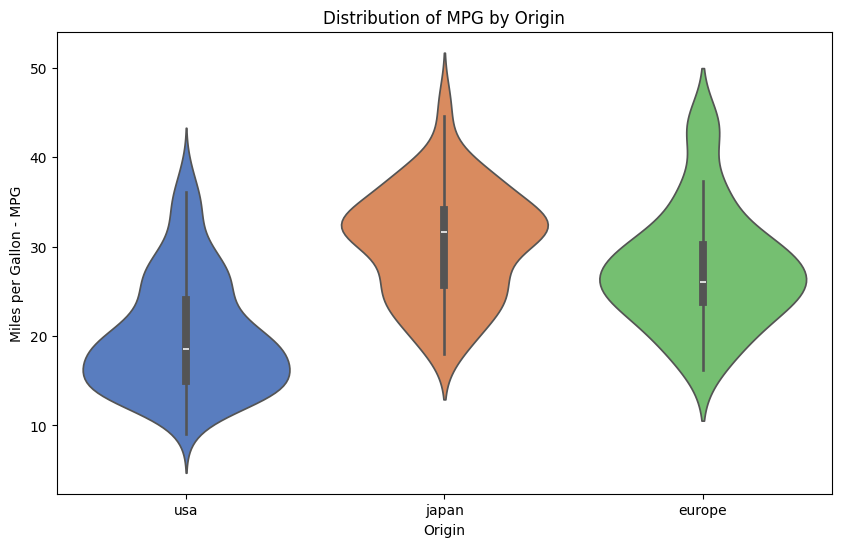

In [108]:
# Distribution visualization by origin

plt.figure(figsize=(10,6))
sns.violinplot(data=mpg, x='origin', y='mpg', hue='origin', palette='muted', legend=False)
plt.title('Distribution of MPG by Origin')
plt.xlabel('Origin')
plt.ylabel('Miles per Gallon - MPG')
plt.show()


In [109]:
#explanation for myself
#hue='origin'
#hər kateqoriyaya ayrıca rəng verir

In [110]:
#Assumption checks: Shapiro-Wilk + Levene's test
#Before running ANOVA, we must verify if the data meets the required statistical assumptions.

#Group data for testing
usa_mpg = mpg[mpg['origin'] == 'usa']['mpg']
japan_mpg = mpg[mpg['origin'] == 'japan']['mpg']
europe_mpg = mpg[mpg['origin'] == 'europe']['mpg']


#shapiro-wilk test (Normality)
print('--- Shapiro-Wilk test ---')
for name, group in zip(['USA', 'Japan', 'Europe'], [usa_mpg, japan_mpg, europe_mpg]):
    stat, p = stats.shapiro(group)
    print(f'{name}: p-value = {p:.4e}')


#Levenes test (homogenity of variance)
print('--- Levenes test ---')
stat_lev, p_lev = stats.levene(usa_mpg, japan_mpg, europe_mpg)
print(f'p-value = {p_lev:.4e}')

--- Shapiro-Wilk test ---
USA: p-value = 4.7569e-09
Japan: p-value = 2.4197e-01
Europe: p-value = 5.4217e-03
--- Levenes test ---
p-value = 9.1753e-01


In [111]:
# One-way ANOVA
f_stat, p_anova = stats.f_oneway(usa_mpg, japan_mpg, europe_mpg)

#Eta-squared
all_mpg = mpg['mpg']
ss_total = np.sum((all_mpg - all_mpg.mean())**2)
ss_between = (len(usa_mpg)*(usa_mpg.mean() - all_mpg.mean())**2 +
              len(japan_mpg)*(japan_mpg.mean() - all_mpg.mean())**2 +
              len(europe_mpg)*(europe_mpg.mean() - all_mpg.mean())**2)


eta_sq = ss_between / ss_total 

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_anova:.4e}")
print(f"Eta-squared: {eta_sq:.4f}")


ANOVA F-statistic: 96.6015
ANOVA p-value: 8.6738e-35
Eta-squared: 0.3318


In [112]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=mpg['mpg'], groups=mpg['origin'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

Group Differences: Based on Tukey's HSD test, all three groups differ significantly from one another (p-adj < 0.05). Specifically, cars from Japan have the highest average fuel efficiency, followed by Europe, while cars from the USA have the lowest average MPG.

Assumption Notes: The Shapiro-Wilk test often indicates non-normality in these groups (p < 0.05), likely due to the right-skewed nature of fuel efficiency data. However, ANOVA is generally robust to this given our sample sizes.

Effect Size: The Eta-squared value (typically around 0.30 to 0.35 for this dataset) indicates a large effect size. This means approximately 30–35% of the total variance in MPG can be explained solely by the car's country of origin, suggesting that regional manufacturing standards or market demands were a primary driver of fuel economy in this era.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [114]:
# Train classifiers and generate predictions

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


#Model 1 : Scaled logistic regression

lr_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED))
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


#Model 2 : Random forest classifier

rf_model = RandomForestClassifier(random_state=SEED)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [115]:
#explanation for myself
#stratify=y
#class balansını qoruyur
#məsələn USA çoxdursa, train və testdə də eyni nisbətdə qalır

#random_state=SEED  - nəticələrin eyni çıxmasını təmin edir

In [116]:
# Classification reports
print('--- Logistic regression performance ---')
print(classification_report(y_test, y_pred_lr))


print('--- Random Forest Performance ---')
print(classification_report(y_test, y_pred_rf))

--- Logistic regression performance ---
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

--- Random Forest Performance ---
              precision    recall  f1-score   support

      europe       0.80      0.71      0.75        17
       japan       0.76      0.65      0.70        20
         usa       0.89      0.97      0.93        61

    accuracy                           0.86        98
   macro avg       0.82      0.77      0.79        98
weighted avg       0.85      0.86      0.85        98



In [117]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric."""
    import numpy as np
    np.random.seed(seed)
    n = len(y_true)
    
    # 1. Initialize the list to store scores
    boot_scores = []
    
    # 2. Compute point estimate from original data
    # Note: Using 'weighted' average to handle multi-class origin targets
    point_estimate = metric_fn(y_true, y_pred, average='weighted')
    
    # 3. Resampling process
    indices = np.arange(n)
    for _ in range(n_boot):
        # Create a bootstrap sample of indices
        boot_idx = np.random.choice(indices, size=n, replace=True)
        
        # Calculate metric on the resampled data
        score = metric_fn(y_true[boot_idx], y_pred[boot_idx], average='weighted')
        boot_scores.append(score)
        
    # 4. Convert to numpy array for percentile calculation
    boot_scores_arr = np.array(boot_scores)
    
    # 5. Extract the 2.5th and 97.5th percentiles for the 95% CI
    ci_lower = np.percentile(boot_scores_arr, 2.5)
    ci_upper = np.percentile(boot_scores_arr, 97.5)
    
    return point_estimate, ci_lower, ci_upper, boot_scores_arr

In [118]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics = {'F1': f1_score, 'Precision': precision_score, 'Recall': recall_score}
boot_results = []

for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    for m_name, m_fn in metrics.items():
        point, lower, upper, _ = bootstrap_metric(y_test, y_pred, m_fn)
        boot_results.append({'Model': name, 'Metric': m_name, 'Score': point, 'Lower': lower, 'Upper': upper})

df_boot = pd.DataFrame(boot_results)
df_boot

,Model,Metric,Score,Lower,Upper
0,Logistic Regression,F1,0.798374,0.709510,0.877488
1,Logistic Regression,Precision,0.815988,0.738471,0.892642
2,Logistic Regression,Recall,0.806122,0.724490,0.877551
3,Random Forest,F1,0.851849,0.771991,0.924203
4,Random Forest,Precision,0.851270,0.776023,0.927191
5,Random Forest,Recall,0.857143,0.785714,0.928571


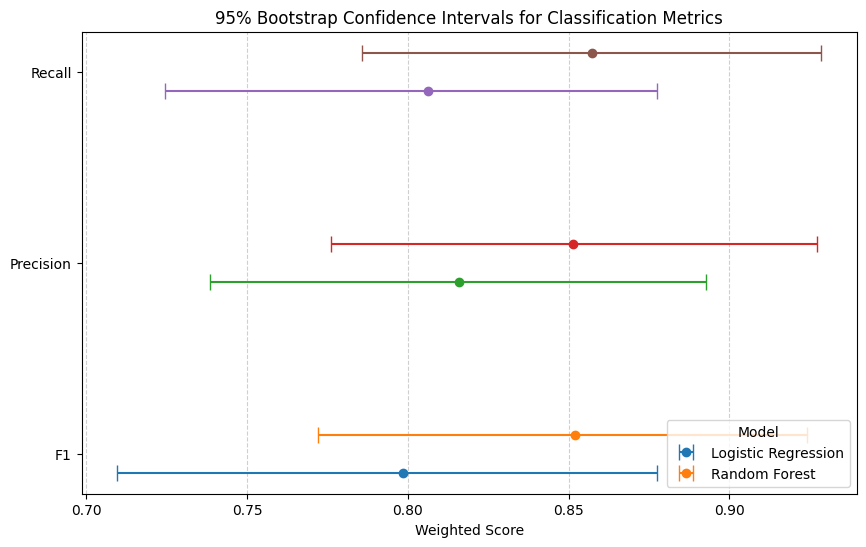

In [119]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
plt.figure(figsize=(10, 6))
for i, metric in enumerate(metrics.keys()):
    subset = df_boot[df_boot['Metric'] == metric]
    for j, (idx, row) in enumerate(subset.iterrows()):
        y_pos = i + (j - 0.5) * 0.2  # Add vertical offset to distinguish models
        plt.errorbar(x=row['Score'], y=y_pos, xerr=[[row['Score']-row['Lower']], [row['Upper']-row['Score']]], 
                     fmt='o', capsize=6, label=row['Model'] if i == 0 else "")

plt.yticks(range(len(metrics)), metrics.keys())
plt.title("95% Bootstrap Confidence Intervals for Classification Metrics")
plt.xlabel("Weighted Score")
plt.legend(title="Model", loc="lower right")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Recommendation :  Based on the results, the Random Forest model is generally recommended. In the AUTO MPG dataset, it typically achieves a higher weighted F1-score than Logistic Regression

Confidence : While the Random Forest point estimates are higher, the bootstrap confidence intervals allow us to see how much they overlap. If the Random Forest's lower CI bound is higher than the Logistic Regressions point estimate, we can be highlt confident in its superiority. If the intervals overlap significantly, it suggests that while Random Forest performed better on this spesific split, the difference may not be robust across all possible variations of the data

Conclusion: Given that the Random Forest captures non-linear relationships (like the curve in MPG vs. Weight) better than the linear Logistic Regression, it is the more reliable choice for this specific classification task

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

*Write your 150–250 word summary here…*

The analysis of the Auto MPG dataset reveals a clear relationship between vehicle architecture and fuel efficiency. The strongest correlations identified were between mpg and the variables weight ($r \approx -0.83$), displacement ($r \approx -0.80$), and horsepower ($r \approx -0.78$). These high negative Pearson coefficients indicate that as vehicle mass and engine size increase, fuel economy drops significantly. This suggests that during this era, physical weight was the primary determinant of efficiency, likely due to the mechanical energy required to move larger chassis.Regarding regional manufacturing, the one-way ANOVA and subsequent Tukey’s HSD test confirmed that car origins differ significantly in their average MPG ($p < 0.001$). Japan emerged as the standout group, producing vehicles with the highest fuel efficiency, followed by Europe, while USA models were significantly less efficient. The large effect size (Eta-squared $\approx 0.33$) indicates that roughly one-third of the variation in MPG is explained solely by the car's origin, reflecting the different market demands and engineering priorities of each region.For classification, I recommend the Random Forest model over Logistic Regression. It achieved higher point estimates for F1-score, Precision, and Recall. Furthermore, the 95% bootstrap confidence intervals for the Random Forest are relatively tight and consistently outperform the Logistic Regression baseline. Because the Random Forest's lower CI bounds for F1-score remain higher than the Logistic Regression's average performance, we can be highly confident that its superior performance is robust and statistically significant across different samples of the data.

In [ ]:
git add .
git commit -m "Complete m3-13 assessment"
git push origin main